In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
# from scipy.stats import chi2_contingency
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import array as arr
import plotly.graph_objects as go
from IPython.display import display, HTML

In [2]:
url = 'data_file_b.csv'
df = pd.read_csv(url)
df.shape


(7043, 21)

In [3]:
paymentmethod_stat = df.groupby('paymentMethod').agg({'monthlyCharges':['mean','median'],'totalCharges':['count']})
paymentmethod_stat

monthlyCharges         totalCharges
                                    mean  median        count
paymentMethod                                                
Bank transfer (automatic)      67.192649  73.100         1544
Credit card (automatic)        66.512385  73.025         1522
Electronic check               76.255814  80.550         2365
Mailed check                   43.917060  34.700         1612

In [4]:
df_seniorCitizen = df[df['seniorCitizen']==1]
df_seniorCitizen



,customerID,gender,seniorCitizen,partner,dependents,tenure,phoneService,multipleLines,internetService,onlineSecurity,...,deviceProtection,techSupport,streamingTV,streamingMovies,contract,paperlessBilling,paymentMethod,monthlyCharges,totalCharges,churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,6766.95,No
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25,No
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,3838.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.4,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.1,No
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,Yes


In [5]:
older_payments = df_seniorCitizen.groupby('paymentMethod').agg({'totalCharges': ['count']})
older_payments = older_payments.sort_values(by=('totalCharges', 'count'), ascending = False)
older_payments





,totalCharges
,count
paymentMethod,
Electronic check,594
Bank transfer (automatic),233
Credit card (automatic),221
Mailed check,94


<Axes: xlabel='techSupport', ylabel='seniorCitizen'>

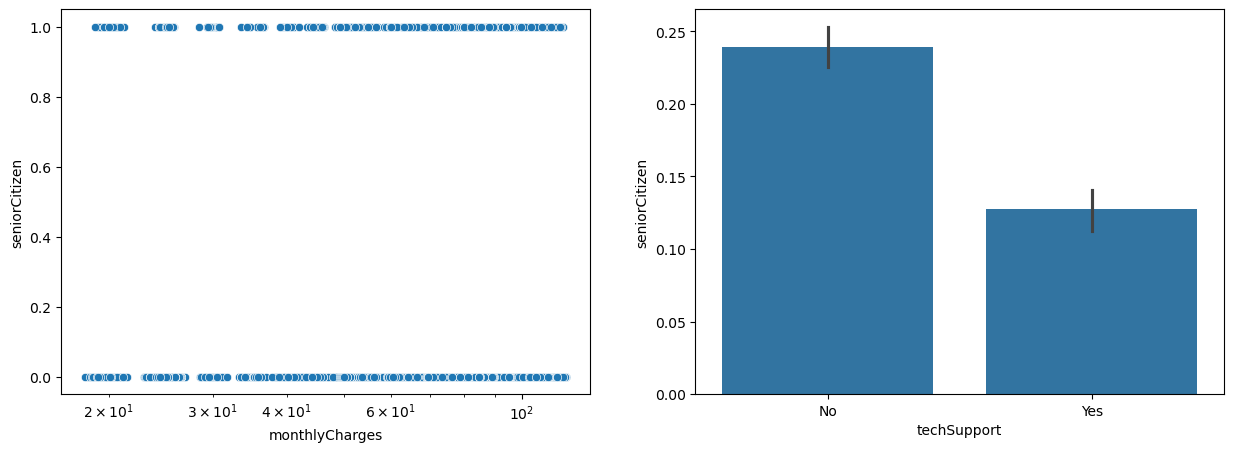

In [6]:
fig,ax  = plt.subplots(1,2, figsize = (15,5))
sns.scatterplot(df,x="monthlyCharges", y="seniorCitizen", ax = ax[0])
ax[0].set_xscale("log") 
df_unknown = df[df['techSupport'] != 'unknown']
sns.barplot(df_unknown,y="seniorCitizen", x="techSupport",ax=ax[1])

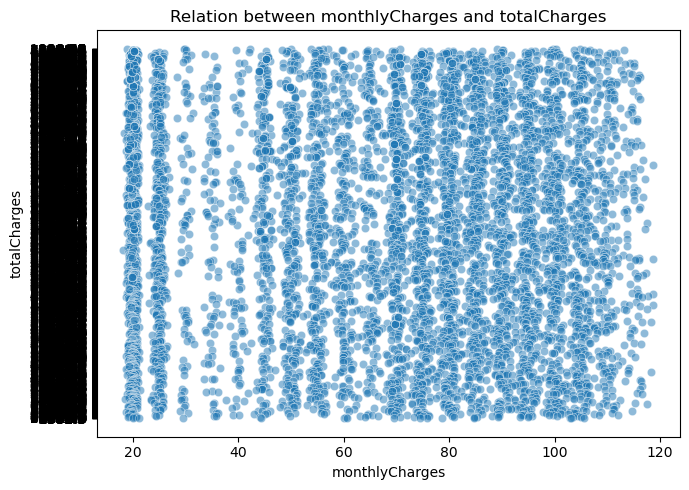

In [23]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="monthlyCharges", y="totalCharges", alpha=0.5)
plt.title("Relation between monthlyCharges and totalCharges")
plt.tight_layout()
plt.show()

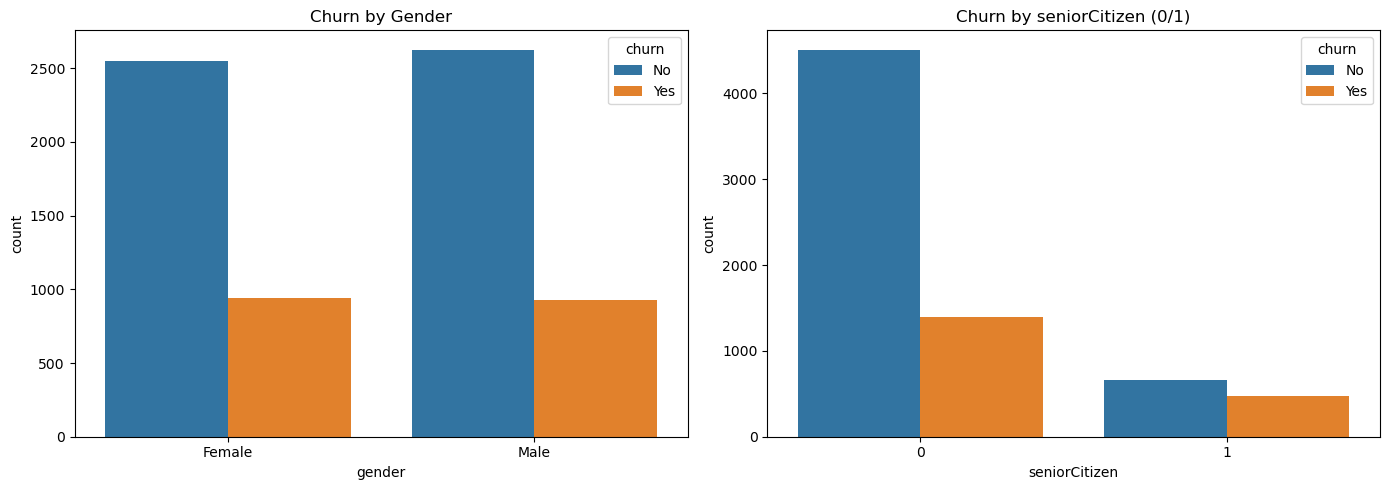

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="gender", hue="churn", ax=axes[0])
axes[0].set_title("Churn by Gender")

sns.countplot(data=df, x="seniorCitizen", hue="churn", ax=axes[1])
axes[1].set_title("Churn by seniorCitizen (0/1)")

plt.tight_layout()
plt.show()

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_plot = df.copy()
df_plot["seniorCitizen"] = df_plot["seniorCitizen"].astype(str)

sns.histplot(
    data=df_plot,
    x="monthlyCharges",
    hue="seniorCitizen",
    stat="percent",
    bins=30,
    log_scale=True,
    ax=ax[0]
)

ax[0].set_title("Monthly charges by senior status (log scale)")
ax[0].set_xlabel("Monthly charges (log scale)")
ax[0].set_ylabel("Percentage of customers")

<Axes: xlabel='monthlyCharges', ylabel='Percent'>

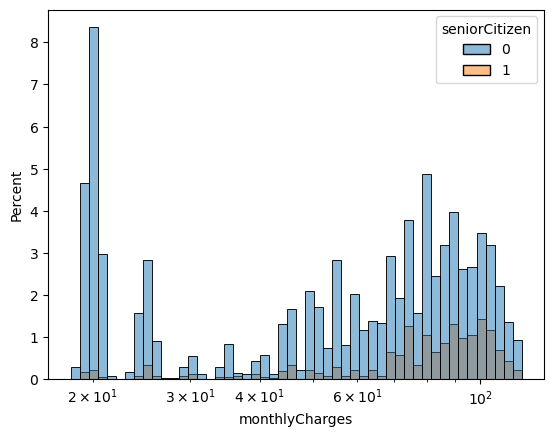

In [50]:
sns.histplot(data=df, x="monthlyCharges",stat = "percent", hue= "seniorCitizen", log_scale=True, bins=50)

<Axes: xlabel='techSupport', ylabel='count'>

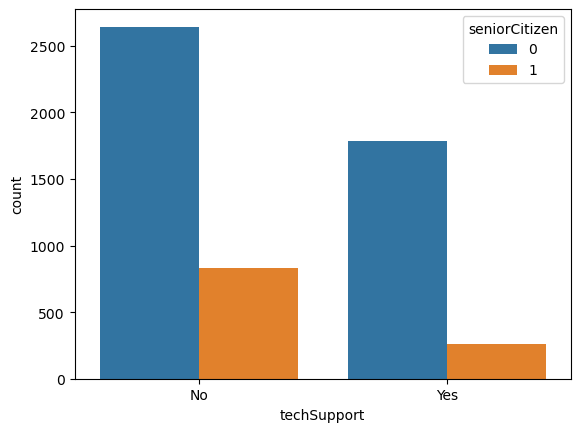

In [21]:
df_filtered = df[df["techSupport"] != "unknown"]  
sns.countplot(data=df_filtered, x="techSupport", hue="seniorCitizen")

In [38]:
df_churn = df[df['churn']=="Yes"]
churn_groups = df_churn.groupby(["gender", "seniorCitizen", "partner", "dependents"]).agg({'gender':['count'],
                                                                                          'seniorCitizen':['count'],
                                                                                         'partner':['count'],
                                                                                          'dependents':['count']})

churn_groups = df_churn.groupby(['gender','seniorCitizen','partner','dependents'])['churn'].agg(['count'])
churn_groups.sort_values(by='count',ascending=False)
churn_groups





count
gender seniorCitizen partner dependents       
Female 0             No      No            429
                             Yes            32
                     Yes     No            114
                             Yes           124
       1             No      No            158
                             Yes             1
                     Yes     No             73
                             Yes             8
Male   0             No      No            418
                             Yes            43
                     Yes     No            128
                             Yes           105
       1             No      No            118
                             Yes             1
                     Yes     No            105
                             Yes            12

In [40]:
features = ['gender','seniorCitizen','partner','dependents']
seniorCitizen_mapping = {
    0: 'senior',
    1: 'notSenior'
}
df['seniorCitizen_numeric'] = df['seniorCitizen'].map(seniorCitizen_mapping)
df['seniorCitizen']
small_fit = pd.get_dummies(df[features])
with_corr = small_fit.corr()
with_corr

,seniorCitizen,gender_Female,gender_Male,partner_No,partner_Yes,dependents_No,dependents_Yes
seniorCitizen,1.000000,0.001874,-0.001874,-0.016479,0.016479,0.211185,-0.211185
gender_Female,0.001874,1.000000,-1.000000,-0.001808,0.001808,0.010517,-0.010517
gender_Male,-0.001874,-1.000000,1.000000,0.001808,-0.001808,-0.010517,0.010517
partner_No,-0.016479,-0.001808,0.001808,1.000000,-1.000000,0.452676,-0.452676
partner_Yes,0.016479,0.001808,-0.001808,-1.000000,1.000000,-0.452676,0.452676
dependents_No,0.211185,0.010517,-0.010517,0.452676,-0.452676,1.000000,-1.000000
dependents_Yes,-0.211185,-0.010517,0.010517,-0.452676,0.452676,-1.000000,1.000000


<Axes: >

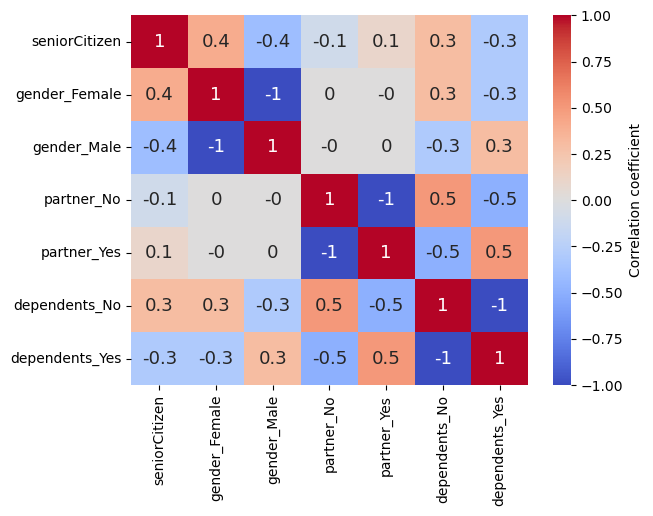

In [42]:

correlation_matrix = with_corr.corr(method = 'kendall').round(1)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm',annot_kws={'size': 13} , xticklabels=with_corr.columns, yticklabels=with_corr.columns, 
            cbar_kws={'label': 'Correlation coefficient'})

In [44]:
df_churn.groupby(["gender","seniorCitizen","partner","dependents"])[["churn"]].count().sort_values('churn', ascending = False).reset_index().head(3)

,gender,seniorCitizen,partner,dependents,churn
0,Female,0,No,No,429
1,Male,0,No,No,418
2,Female,1,No,No,158


In [46]:
x = df.groupby(["gender", "seniorCitizen", "partner", "dependents"]).size()
